# TAPSE

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import os

In [2]:
import pandas as pd

# Load everything (fast)
df_color = pd.read_parquet("/home/sagemaker-user/user-default-efs/vjepa2/classifier/output/color_inference_18m/predictions.parquet")
df_view = pd.read_parquet("/home/sagemaker-user/user-default-efs/vjepa2/classifier/output/view_inference_18m/predictions.parquet")

In [3]:
df_color.head()

,s3_uri,is_color,confidence,status
0,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111357.10353287.mp4,Yes,0.915527,OK
1,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111381.10353325.mp4,No,0.935547,OK
2,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111395.10353351.mp4,Yes,0.906738,OK
3,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714578744.1.1703111357.7964267.mp4,No,0.963379,OK
4,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714578744.1.1703111378.7964301.mp4,No,0.956055,OK


In [4]:
df_view.head()

,s3_uri,prediction,confidence,status
0,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111357.10353287.mp4,A4C,0.573242,OK
1,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111381.10353325.mp4,Exclude,0.835449,OK
2,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714512485.1.1703111395.10353351.mp4,Exclude,0.561035,OK
3,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714578744.1.1703111357.7964267.mp4,Exclude,0.439697,OK
4,s3://echodata25/results/echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/1.2.276.0.7230010.3.1.3.1714512485.1.1703111357.10353286/1.2.276.0.7230010.3.1.4.1714578744.1.1703111378.7964301.mp4,PSAX-PM,0.822266,OK


In [5]:
len(df_view)

18236344

In [6]:
# --- 1. Color Prediction Stats ---
print("--- Color Model Performance ---")
# Group by the class label ('is_color') and calculate mean/count for confidence
color_stats = df_color.groupby('is_color')['confidence'].agg(['mean', 'count', 'std'])
print(color_stats)

# --- 2. View Prediction Stats ---
print("\n--- View Model Performance ---")
# Group by the class label ('prediction') and calculate mean/count for confidence
view_stats = df_view.groupby('prediction')['confidence'].agg(['mean', 'count', 'std'])
print(view_stats)

--- Color Model Performance ---
              mean     count       std
is_color                              
          0.000000       115  0.000000
No        0.941629  11037415  0.042220
Yes       0.889147   7165998  0.048577

--- View Model Performance ---
                mean    count       std
prediction                             
            0.000000      115  0.000000
A2C         0.742327  1603746  0.180573
A3C         0.738329  1092423  0.155512
A4C         0.770572  3167729  0.161338
A5C         0.684251   687503  0.154562
Exclude     0.611953  2179938  0.171393
PLAX        0.845911  2529914  0.127321
PSAX-AP     0.576374   352876  0.133527
PSAX-AV     0.773970  1893286  0.162147
PSAX-MV     0.579781   356119  0.134596
PSAX-PM     0.671625  1305956  0.176611
SSN         0.700110   213917  0.142802
Subcostal   0.747768  1299466  0.139581
TEE         0.880079  1553356  0.089863


# Syngo

In [7]:
data_dir = 'data/dataset/Lee_Echo_Syngo'
adler = pd.read_csv(os.path.join(data_dir, 'Adler.csv'))
analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
analytics_study = pd.read_csv(os.path.join(data_dir, 'AnalyticsStudy.csv'))
department = pd.read_csv(os.path.join(data_dir, 'Department.csv'))
field_map = pd.read_csv(os.path.join(data_dir, 'FieldMap.csv'))
measurement_type = pd.read_csv(os.path.join(data_dir, 'MeasurementType.csv'))
modalities = pd.read_csv(os.path.join(data_dir, 'Modalities.csv'))
observations = pd.read_csv(os.path.join(data_dir, 'Observations.csv'))
study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))

/tmp/ipykernel_2728075/1852141919.py:3: DtypeWarning: Columns (18,19,23,24,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
/tmp/ipykernel_2728075/1852141919.py:10: DtypeWarning: Columns (6,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))


In [8]:
aws_uhn = pd.read_csv('aws/aws_uhn.csv', index_col=0)
print(aws_uhn.shape)

(320854, 9)


In [9]:
data_dir = 'data/dataset/Lee_Syngo_AnalyticMeasurement'
analytics_measure = pd.read_csv(os.path.join(data_dir, 'AnalyticsMeasure_Total.csv'))

In [10]:
analytics_measure.head()

,StudyRef,MeasurementTypeRef,MeasurementName,Value,Units
0,1000710,126,Height,189.000000,cm
1,1000710,127,Weight,97.300000,kg
2,1000710,140,Regenerate Study Structured Report,1.000000,unitless
3,1000710,10650,Stress Data Persisted,1.000000,unitless
4,1000710,13019,BSA (Boyd),2.265217,m2


In [11]:
len(analytics_measure)

26128284

In [12]:
syn_lvef = analytics_measure.loc[analytics_measure['MeasurementName'] == 'TAPSE (M-mode)']

In [13]:
syn_lvef.head()

,StudyRef,MeasurementTypeRef,MeasurementName,Value,Units
103,1000712,14187,TAPSE (M-mode),29.000000,cm
1046,1000731,14187,TAPSE (M-mode),2.700000,cm
2207,1000752,14520,TAPSE (M-mode),1.500000,cm
2343,1000753,14187,TAPSE (M-mode),1.833315,cm
2597,1000754,14520,TAPSE (M-mode),17.000000,cm


In [14]:
syn_df = syn_lvef

In [15]:
# Create a boolean mask to identify matching StudyRef values
matching_mask = syn_df['StudyRef'].isin(aws_uhn['STUDY_REF'])

# Count the number of matches (True values)
number_of_matches = matching_mask.sum()

# Get the total number of unique studies in mv_obs for context
total_unique_studies = syn_df['StudyRef'].nunique()

print(f"\nTotal unique StudyRef values in syn_df: {total_unique_studies}")
print(f"Number of 'StudyRef' values from syn_df that are in aws_uhn: {number_of_matches}")
print(f"Percentage of matching studies: {(number_of_matches / total_unique_studies) * 100:.2f}%")


Total unique StudyRef values in syn_df: 101094
Number of 'StudyRef' values from syn_df that are in aws_uhn: 57204
Percentage of matching studies: 56.58%


In [16]:
import pandas as pd

# Step 1: Merge the two DataFrames
# We'll merge 'syn_df' (lvef) with 'aws_uhn' using 'StudyRef' and 'STUDY_REF' as the keys.
merged_df = pd.merge(syn_df, aws_uhn, left_on='StudyRef', right_on='STUDY_REF', how='inner')

# Step 2: Define the desired columns in the correct order
final_columns = [
    'STUDY_REF',
    's3_key',
    'Value',
    'PATIENT_ID',
    'STUDY_DATE',
    'STUDY_TIME',
    'DeidentifiedStudyID',
    'OriginalStudyID'
]

# # Step 3: Create the new table with only the specified columns
syn_df_labels = merged_df[final_columns]

# convert numeric date to datetime
syn_df_labels['STUDY_DATE'] = pd.to_datetime(
    syn_df_labels['STUDY_DATE'].astype(str), 
    format='%Y%m%d'
)

# now sortable by date
syn_df_labels = syn_df_labels.sort_values('STUDY_DATE')
syn_df_labels['STUDY_DATE'] = syn_df_labels['STUDY_DATE'].dt.strftime('%Y-%m-%d')

/tmp/ipykernel_2728075/2188486175.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syn_df_labels['STUDY_DATE'] = pd.to_datetime(


In [17]:
len(syn_df_labels)

58120

In [18]:
syn_df_labels.head()

,STUDY_REF,s3_key,Value,PATIENT_ID,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID
0,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.000000,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485
30,1001171,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725196397.4284807/,22.000000,3937709,2015-07-22,130931.0,1.2.276.0.7230010.3.1.2.895693665.1.1725196397.4284807,1.3.12.2.1107.5.8.9.1002655211149138.20150722170341281
31,1001174,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196269.2222543/,2.133312,4228866,2015-07-22,130831.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196269.2222543,1.3.12.2.1107.5.8.9.1002655211149138.20150722154448578
32,1001175,echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862/,25.000000,4245026,2015-07-22,131611.0,1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862,1.3.12.2.1107.5.8.9.1002655211149138.20150722131904569
33,1001176,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714/,28.000000,4291335,2015-07-22,131241.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714,1.3.12.2.1107.5.8.9.1002655211149138.20150722154701631


#### **To Do: Link to highest confidence + b/w A4C video in each study (maybe multiple, above a threshold). Do a patient-disjoint temporal split. Normalize regression values. Do the same for HeartLab.**

In [19]:
import pandas as pd
import numpy as np

def create_patient_disjoint_temporal_split(df, 
                                           patient_col='PATIENT_ID', 
                                           time_col='STUDY_DATE', 
                                           ratios=[0.7, 0.1, 0.2]):
    """
    Splits dataframe strictly by patient, ordered by time, respecting data volume ratios.
    """
    # 1. Get unique patients with their temporal metadata and study volume
    patient_meta = df.groupby(patient_col).agg(
        last_study_date=(time_col, 'max'),
        study_count=('s3_key', 'count') # Or any non-null col
    ).reset_index()

    # 2. Sort patients by time (Temporal aspect)
    patient_meta = patient_meta.sort_values(by='last_study_date')

    # 3. Calculate cumulative counts to find split indices based on VOLUME (not just patient count)
    total_studies = len(df)
    patient_meta['cumulative_studies'] = patient_meta['study_count'].cumsum()
    
    # Define thresholds
    train_cutoff = total_studies * ratios[0]
    val_cutoff = total_studies * (ratios[0] + ratios[1])

    # 4. Assign split labels
    def get_split_label(cumulative_count):
        if cumulative_count <= train_cutoff:
            return 'train'
        elif cumulative_count <= val_cutoff:
            return 'val'
        else:
            return 'test'

    patient_meta['split'] = patient_meta['cumulative_studies'].apply(get_split_label)

    # 5. Merge split labels back to original dataframe
    df_split = df.merge(patient_meta[[patient_col, 'split']], on=patient_col, how='left')

    # Create the subsets
    train_df = df_split[df_split['split'] == 'train'].copy()
    val_df = df_split[df_split['split'] == 'val'].copy()
    test_df = df_split[df_split['split'] == 'test'].copy()

    return train_df, val_df, test_df

# --- Usage ---

# Ensure STUDY_DATE is datetime (looks like you did this in Image 3, but good to double check)
syn_df_labels['STUDY_DATE'] = pd.to_datetime(syn_df_labels['STUDY_DATE'])

train_df, val_df, test_df = create_patient_disjoint_temporal_split(syn_df_labels)

# --- Verification & Stats ---
print(f"Total Studies: {len(syn_df_labels)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(syn_df_labels):.1%}) | Dates: {train_df['STUDY_DATE'].min().date()} to {train_df['STUDY_DATE'].max().date()}")
print(f"Val:   {len(val_df)} ({len(val_df)/len(syn_df_labels):.1%}) | Dates: {val_df['STUDY_DATE'].min().date()} to {val_df['STUDY_DATE'].max().date()}")
print(f"Test:  {len(test_df)} ({len(test_df)/len(syn_df_labels):.1%}) | Dates: {test_df['STUDY_DATE'].min().date()} to {test_df['STUDY_DATE'].max().date()}")

# Verify Patient Disjointness
train_pats = set(train_df['PATIENT_ID'])
val_pats = set(val_df['PATIENT_ID'])
test_pats = set(test_df['PATIENT_ID'])

assert len(train_pats.intersection(val_pats)) == 0, "Leakage between Train and Val!"
assert len(train_pats.intersection(test_pats)) == 0, "Leakage between Train and Test!"
assert len(val_pats.intersection(test_pats)) == 0,   "Leakage between Val and Test!"

print("\nSUCCESS: Splits are patient-disjoint and temporally ordered.")

Total Studies: 58120
Train: 40684 (70.0%) | Dates: 2015-07-22 to 2019-01-22
Val:   5811 (10.0%) | Dates: 2015-07-22 to 2019-03-12
Test:  11625 (20.0%) | Dates: 2015-07-22 to 2019-05-27

SUCCESS: Splits are patient-disjoint and temporally ordered.


In [20]:
print(len(train_df))
train_df.head()

40684


,STUDY_REF,s3_key,Value,PATIENT_ID,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID,split
0,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.000000,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train
1,1001171,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725196397.4284807/,22.000000,3937709,2015-07-22,130931.0,1.2.276.0.7230010.3.1.2.895693665.1.1725196397.4284807,1.3.12.2.1107.5.8.9.1002655211149138.20150722170341281,train
2,1001174,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196269.2222543/,2.133312,4228866,2015-07-22,130831.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196269.2222543,1.3.12.2.1107.5.8.9.1002655211149138.20150722154448578,train
3,1001175,echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862/,25.000000,4245026,2015-07-22,131611.0,1.2.276.0.7230010.3.1.2.895627313.1.1725195914.3248862,1.3.12.2.1107.5.8.9.1002655211149138.20150722131904569,train
4,1001176,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714/,28.000000,4291335,2015-07-22,131241.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725196295.2222714,1.3.12.2.1107.5.8.9.1002655211149138.20150722154701631,train


# A4C

In [24]:
import pandas as pd

# Use strict thresholds for cleaner TAPSE signals
color_threshold = 0.90
view_threshold = 0.75 # Adjusted to be slightly near the mean (0.77)

def add_video_paths_to_splits(train_df, val_df, test_df, df_color, df_view):
    # --- Step 1: Filter Video Metadata ---
    valid_color = df_color[(df_color['is_color'] == 'No') & (df_color['confidence'] > color_threshold)]
    valid_view = df_view[(df_view['prediction'] == 'A4C') & (df_view['confidence'] > view_threshold)]
    
    # Inner join here ensures we only keep videos that pass BOTH checks
    valid_videos = pd.merge(valid_color, valid_view, on='s3_uri', suffixes=('_color', '_view'))

    # --- Step 2: Fix the Join Key (Safer Version) ---
    def extract_study_key(uri):
        # Input: s3://echodata25/results/echo-study/STUDY_UID/SERIES_UID/video.mp4
        clean_path = uri.replace("s3://echodata25/results/", "")
        parts = clean_path.split('/')
        
        # Standardize: Result is "echo-study/STUDY_UID" (NO TRAILING SLASH)
        # This is usually safer for merging with other dataframes.
        return f"{parts[0]}/{parts[1]}"

    valid_videos['study_join_key'] = valid_videos['s3_uri'].apply(extract_study_key)

    # --- Pre-Merge Check (Optional but Recommended) ---
    # Ensure your split dataframes also don't have trailing slashes
    train_df['s3_key'] = train_df['s3_key'].str.rstrip('/')
    val_df['s3_key'] = val_df['s3_key'].str.rstrip('/')
    test_df['s3_key'] = test_df['s3_key'].str.rstrip('/')

    # --- Step 3: Merge with Splits ---
    # Validate: "one-to-many" merge (1 study -> N videos)
    train_expanded = pd.merge(train_df, valid_videos, left_on='s3_key', right_on='study_join_key', how='inner')
    val_expanded = pd.merge(val_df, valid_videos, left_on='s3_key', right_on='study_join_key', how='inner')
    test_expanded = pd.merge(test_df, valid_videos, left_on='s3_key', right_on='study_join_key', how='inner')

    # Cleanup
    cols_to_drop = ['study_join_key']
    train_expanded.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    val_expanded.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    test_expanded.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    return train_expanded, val_expanded, test_expanded

# --- Run ---
train_final, val_final, test_final = add_video_paths_to_splits(
    train_df, val_df, test_df, df_color, df_view
)

print(f"Total Videos -> {len(train_final) + len(val_final) + len(test_final)}")

Total Videos -> 305942


In [26]:
print(f"Train: {len(train_df)} studies -> {len(train_final)} videos")
print(f"Val:   {len(val_df)} studies -> {len(val_final)} videos")
print(f"Test:  {len(test_df)} studies -> {len(test_final)} videos")

Train: 40684 studies -> 211611 videos
Val:   5811 studies -> 31099 videos
Test:  11625 studies -> 63232 videos


In [22]:
train_final.head()

,STUDY_REF,s3_key,Value,PATIENT_ID,STUDY_DATE,STUDY_TIME,DeidentifiedStudyID,OriginalStudyID,split,s3_uri,is_color,confidence_color,status_color,prediction,confidence_view,status_view
0,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.0,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895627313.1.1725196822.3252190.mp4,No,0.958984,OK,A4C,0.896484,OK
1,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.0,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725197990.2758722.mp4,No,0.940918,OK,A4C,0.893066,OK
2,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.0,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725198003.2758772.mp4,No,0.956543,OK,A4C,0.884766,OK
3,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.0,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.1667523124.1.1725196991.2348140.mp4,No,0.957520,OK,A4C,0.900391,OK
4,1000712,echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/,29.0,3414620,2015-07-22,80437.0,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,1.3.12.2.1107.5.8.9.1002655211149138.20150722112601485,train,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895693665.1.1725197807.4289965.mp4,No,0.951660,OK,A4C,0.860352,OK


# Stats


==================== TRAIN STATISTICS (RAW) ====================
count    211611.000000
mean          2.044930
std           1.782185
min           0.000000
1%            0.700000
5%            1.070000
25%           1.600000
50%           1.900000
75%           2.271111
95%           2.800000
99%           3.500000
99.9%        25.000000
max         202.000000
Name: Value, dtype: float64

Invalid Values -> Zeros: 5 | Negatives: 0


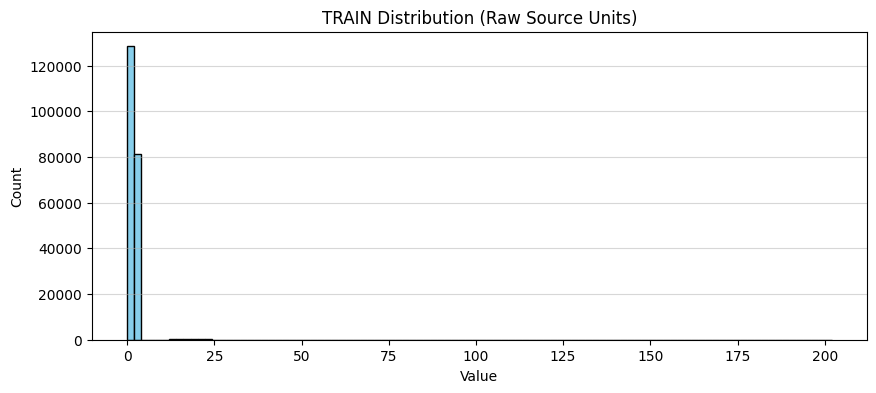


==================== VAL STATISTICS (RAW) ====================
count    31099.000000
mean         1.912467
std          0.999483
min          0.110000
1%           0.700000
5%           1.000000
25%          1.500000
50%          1.870000
75%          2.200000
95%          2.800000
99%          3.300000
99.9%       18.000000
max         25.000000
Name: Value, dtype: float64

Invalid Values -> Zeros: 0 | Negatives: 0


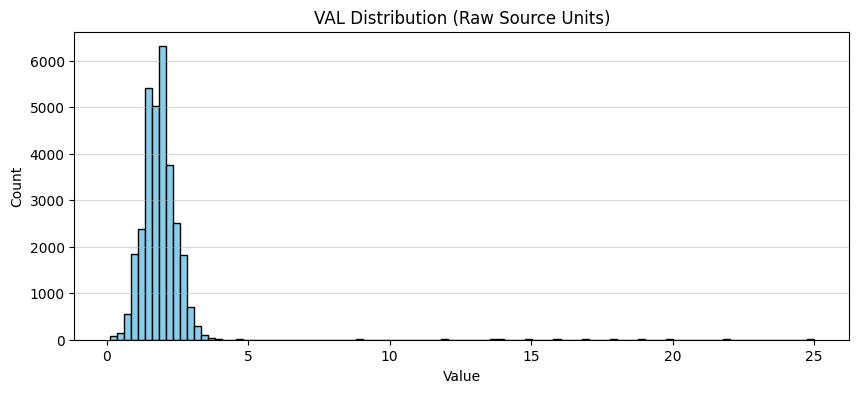


==================== TEST STATISTICS (RAW) ====================
count    63232.000000
mean         1.870999
std          0.842471
min          0.060000
1%           0.653333
5%           1.000000
25%          1.500000
50%          1.800000
75%          2.200000
95%          2.777702
99%          3.200000
99.9%       15.000000
max         24.000000
Name: Value, dtype: float64

Invalid Values -> Zeros: 0 | Negatives: 0


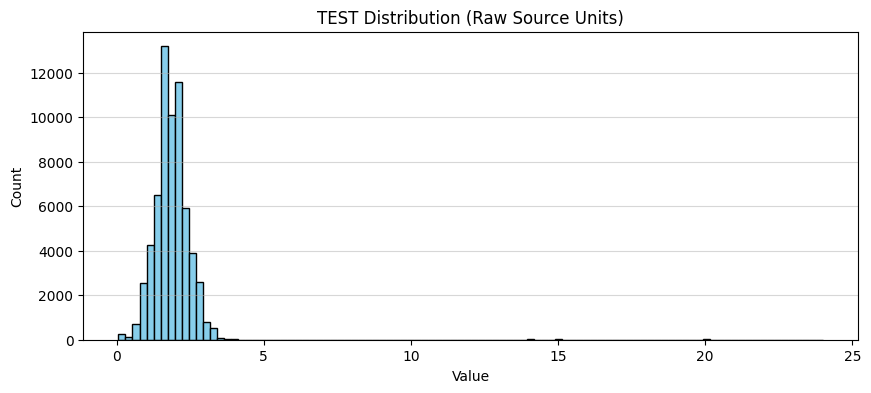

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# List of your dataframes and their names
splits = [
    ('TRAIN', train_final),
    ('VAL', val_final),
    ('TEST', test_final)
]

# Loop through each split to print stats and plot
for name, df in splits:
    print(f"\n{'='*20} {name} STATISTICS (RAW) {'='*20}")
    
    # 1. Numerical Stats
    # Added 99.9% to see the extreme max outliers
    stats = df['Value'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
    print(stats)
    
    # 2. Invalid Value Counts
    zeros = (df['Value'] == 0).sum()
    negs = (df['Value'] < 0).sum()
    print(f"\nInvalid Values -> Zeros: {zeros} | Negatives: {negs}")

    # 3. Visual Check (Histogram)
    plt.figure(figsize=(10, 4))
    # We dropna() just for plotting so it doesn't crash
    plt.hist(df['Value'].dropna(), bins=100, color='skyblue', edgecolor='black')
    plt.title(f'{name} Distribution (Raw Source Units)')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.5)
    plt.show()

# Cleaning

In [32]:
import pandas as pd
import numpy as np

def clean_tapse_units(val):
    """
    Standardizes TAPSE to cm and clips to physiological max.
    Logic:
    1. Filter Garbage: val < 0 or val > 100 -> NaN
    2. Normalize Units: 
       - 8.0 <= val <= 100: Likely Millimeters -> Divide by 10
       - 0 < val < 8.0: Likely Centimeters -> Keep
    3. Clip: Cap values at 4.0 cm (Physiological Max)
    """
    # Handle NaN or non-numeric types gracefully
    if pd.isna(val):
        return np.nan
        
    # 1. Drop obvious errors (negatives, zeros, massive outliers)
    if val <= 0 or val > 100:
        return np.nan
    
    # 2. CASE: Millimeters (e.g., 18, 24, 29) -> Convert to cm
    # We use 8.0 as a safe cutoff (anything above 8 is assumed to be mm)
    if val >= 8.0:
        val = val / 10.0
    
    # 3. CLIP: Cap at 4.0 cm
    # Even if valid, > 4.0 is likely hyperdynamic or measurement overshoot.
    # Clipping is safer than dropping to keep the data.
    if val > 4.0:
        val = 4.0
        
    return val

def process_and_report(df, name):
    print(f"\n{'='*20} PROCESSING {name.upper()} SET {'='*20}")
    
    # --- 1. Capture Before Stats ---
    total_rows = len(df)
    
    # --- 2. Apply Cleaning ---
    df_clean = df.copy()
    df_clean['tapse_clean'] = df_clean['Value'].apply(clean_tapse_units)
    
    # Drop NaNs (failed cleaning)
    df_clean = df_clean.dropna(subset=['tapse_clean'])
    
    # --- 3. Capture After Stats ---
    valid_rows = len(df_clean)
    dropped_rows = total_rows - valid_rows
    
    print(f"Original: {total_rows} -> Final: {valid_rows} (Dropped {dropped_rows})")

    print("\n--- Final Statistics (Clipped @ 4.0 cm) ---")
    # Added 'max' to the percentiles to verify the clip worked
    stats = df_clean['tapse_clean'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    print(stats)
    
    # Keep only necessary columns
    df_clean = df_clean[['s3_uri', 'tapse_clean']].rename(columns={'tapse_clean': 'Value'})
    
    return df_clean

# --- EXECUTION ---
train_clean = process_and_report(train_final, "Train")
val_clean = process_and_report(val_final, "Validation")
test_clean = process_and_report(test_final, "Test")

# Final check
print(f"\nMax value in Train: {train_clean['Value'].max()} cm (Should be <= 4.0)")


==================== PROCESSING TRAIN SET ====================

--- BEFORE Cleaning (Raw 'Value') ---
count    211611.000000
mean          2.044930
std           1.782185
min           0.000000
1%            0.700000
5%            1.070000
50%           1.900000
95%           2.800000
99%           3.500000
max         202.000000
Name: Value, dtype: float64

--- Cleaning Impact ---
Original: 211611
Dropped:  7 (0.00%)
Final:    211604 valid videos

--- AFTER Cleaning (Standardized to cm & Clipped @ 4.0) ---
count    211604.000000
mean          1.907744
std           0.523999
min           0.090000
1%            0.700000
5%            1.068889
25%           1.600000
50%           1.900000
75%           2.240000
95%           2.800000
99%           3.200000
max           4.000000
Name: tapse_clean, dtype: float64
Skewness: 0.03

==================== PROCESSING VALIDATION SET ====================

--- BEFORE Cleaning (Raw 'Value') ---
count    31099.000000
mean         1.912467
std      

In [33]:
train_clean.head()

,s3_uri,Value
0,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895627313.1.1725196822.3252190.mp4,2.9
1,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725197990.2758722.mp4,2.9
2,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725198003.2758772.mp4,2.9
3,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.1667523124.1.1725196991.2348140.mp4,2.9
4,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895693665.1.1725197807.4289965.mp4,2.9


# Scaling

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

# 1. Initialize the Scaler
# Standard scaling (Mean=0, Std=1) is ideal for regression losses like MSE
scaler = StandardScaler()

# 2. Fit ONLY on the Training Set
# CRITICAL: Never fit on validation/test data to avoid data leakage
train_values = train_clean['Value'].values.reshape(-1, 1)
scaler.fit(train_values)

print(f"Scaler fitted on TAPSE (cm). Mean: {scaler.mean_[0]:.4f}, Std: {scaler.scale_[0]:.4f}")

# 3. Transform All Splits
# We create a new column 'norm_value' which the model will actually learn to predict
train_clean['norm_value'] = scaler.transform(train_clean['Value'].values.reshape(-1, 1))
val_clean['norm_value']   = scaler.transform(val_clean['Value'].values.reshape(-1, 1))
test_clean['norm_value']  = scaler.transform(test_clean['Value'].values.reshape(-1, 1))

# 4. Save the Scaler
# You will need this later to convert model predictions (e.g., -0.5) back to real cm (e.g., 1.6 cm)
with open('tapse_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to 'tapse_scaler.pkl'")

# --- Verification ---
print("\nNormalization Check (Train Set):")
print(train_clean['norm_value'].describe().round(4))
# Expected: Mean ~ 0.0, Std ~ 1.0

print("\nExample Data (Real cm vs. Normalized):")
print(train_clean[['Value', 'norm_value']].head(5))

Scaler fitted on TAPSE (cm). Mean: 1.9077, Std: 0.5240
Scaler saved to 'tapse_scaler.pkl'

Normalization Check (Train Set):
count    211604.0000
mean          0.0000
std           1.0000
min          -3.4690
25%          -0.5873
50%          -0.0148
75%           0.6341
max           3.9929
Name: norm_value, dtype: float64

Example Data (Real cm vs. Normalized):
   Value  norm_value
0    2.9    1.893625
1    2.9    1.893625
2    2.9    1.893625
3    2.9    1.893625
4    2.9    1.893625


In [36]:
train_clean.head()

,s3_uri,Value,norm_value
0,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895627313.1.1725196822.3252190.mp4,2.9,1.893625
1,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725197990.2758722.mp4,2.9,1.893625
2,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725198003.2758772.mp4,2.9,1.893625
3,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.1667523124.1.1725196991.2348140.mp4,2.9,1.893625
4,s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895693665.1.1725197807.4289965.mp4,2.9,1.893625


In [37]:
import os
import pandas as pd

# 1. Setup Output Directory
output_dir = 'csv'
os.makedirs(output_dir, exist_ok=True)

def write_tapse_csv(df, filename):
    """
    Writes DataFrame to space-separated format (Path Label) for the dataloader:
    - Delimiter: Space
    - Columns: [s3_uri, norm_value]
    - No Header, No Index
    """
    output_path = os.path.join(output_dir, filename)
    
    # Select the relevant columns
    # Column 1: File Path (s3_uri)
    # Column 2: Label (norm_value -> normalized TAPSE)
    export_df = df[['s3_uri', 'norm_value']].copy()
    
    # Write to CSV
    export_df.to_csv(
        output_path, 
        sep=' ',       # Space delimiter (Standard for V-JEPA/VideoMAE)
        header=False,  # No header row
        index=False    # Do not write row numbers
    )
    
    print(f"✅ Saved {len(df)} rows to: {output_path}")
    
    # Verification: Print the first few lines to confirm format
    print(f"--- Preview ({filename}) ---")
    with open(output_path, 'r') as f:
        for _ in range(3):
            print(f.readline().strip())
    print("-" * 30 + "\n")

# 2. Write the files
# Using the standard naming convention: [view]_[mode]_[metric]_[split].csv
write_tapse_csv(train_clean, 'a4c_b_tapse_train.csv')
write_tapse_csv(val_clean,   'a4c_b_tapse_val.csv')
write_tapse_csv(test_clean,  'a4c_b_tapse_test.csv')

✅ Saved 211604 rows to: csv/a4c_b_tapse_train.csv
--- Preview (a4c_b_tapse_train.csv) ---
s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.895627313.1.1725196822.3252190.mp4 1.8936245948552077
s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725197990.2758722.mp4 1.8936245948552077
s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892/1.2.276.0.7230010.3.1.3.895627313.1.1725196662.3251540/1.2.276.0.7230010.3.1.4.842097970.1.1725198003.2758772.mp4 1.8936245948552077
------------------------------

✅ Saved 31099 rows to: csv/a4c_b_tapse_val.csv
--- Preview (a4c_b_tapse_val.csv) ---
s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1725195545.4281887/1.2.276.0.7230010.3.1.3

# Resize

In [2]:
import sagemaker
print(f"SageMaker Version: {sagemaker.__version__}")
# Should print something like 2.23x.x, NOT 3.x.x

from sagemaker.session import Session
import boto3
import pandas as pd
import numpy as np
import os
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker import image_uris

# 1. Initialize Session
try:
    session = Session()
except AttributeError:
    # Fallback if import is still acting up (rare after downgrade)
    session = sagemaker.Session()

region = session.boto_region_name
default_bucket = session.default_bucket()
role = sagemaker.get_execution_role()

print(f"✅ Session Loaded | Bucket: {default_bucket} | Role: {role}")

SageMaker Version: 2.232.0
✅ Session Loaded | Bucket: sagemaker-us-west-2-495467399120 | Role: arn:aws:iam::495467399120:role/service-role/AmazonSageMaker-ExecutionRole-20250409T120880


In [4]:
import pandas as pd
import os

# 1. Load the specific CSVs we saved earlier
# Format is Space-Separated: [s3_uri, norm_value]
cols = ['s3_uri', 'norm_value']

df_train = pd.read_csv('csv/a4c_b_tapse_train.csv', sep=' ', header=None, names=cols)
df_val   = pd.read_csv('csv/a4c_b_tapse_val.csv',   sep=' ', header=None, names=cols)
df_test  = pd.read_csv('csv/a4c_b_tapse_test.csv',  sep=' ', header=None, names=cols)

# 2. Add the 'split' column (This determines the subfolder)
df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

# 3. Combine into a Master DataFrame
# We only need [s3_uri, split] for the resizing job
df_master = pd.concat([df_train, df_val, df_test])[['s3_uri', 'split']]

# 4. Save and Verify
output_file = 'master_list_with_splits.csv'
df_master.to_csv(output_file, index=False, header=False)

print(f"✅ Master list created: {len(df_master)} videos")
print("Preview:")
print(df_master.head(3))

✅ Master list created: 305935 videos
Preview:
                                              s3_uri  split
0  s3://echodata25/results/echo-study-2/1.2.276.0...  train
1  s3://echodata25/results/echo-study-2/1.2.276.0...  train
2  s3://echodata25/results/echo-study-2/1.2.276.0...  train


In [12]:
%%writefile preprocess.py
import os
import cv2
import boto3
import pandas as pd
import argparse
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urlparse

# Settings
TARGET_SIZE = (224, 224)
NUM_THREADS = 16

def get_s3_bucket_key(s3_uri):
    parsed = urlparse(s3_uri)
    return parsed.netloc, parsed.path.lstrip('/')

def process_video(s3_uri, split_name, output_base_dir):
    try:
        bucket, key = get_s3_bucket_key(s3_uri)
        filename = key.split('/')[-1]
        
        save_dir = os.path.join(output_base_dir, split_name, 'a4c')
        os.makedirs(save_dir, exist_ok=True)
        
        local_input = f"/tmp/{filename}"
        local_output = os.path.join(save_dir, filename)

        if os.path.exists(local_output):
            return 1 # Skipped count

        s3 = boto3.client('s3')
        s3.download_file(bucket, key, local_input)

        cap = cv2.VideoCapture(local_input)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        out = cv2.VideoWriter(local_output, fourcc, 30.0, TARGET_SIZE)

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_resized = cv2.resize(frame, TARGET_SIZE)
            out.write(frame_resized)

        cap.release()
        out.release()
        
        if os.path.exists(local_input):
            os.remove(local_input)
            
        return 1 # Success count

    except Exception as e:
        # Print error but don't crash the worker
        print(f"Error processing {s3_uri}: {str(e)}")
        return 0 # Fail count

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--input-dir', type=str, default='/opt/ml/processing/input')
    parser.add_argument('--output-dir', type=str, default='/opt/ml/processing/output')
    args = parser.parse_args()

    # 1. Read CSV
    input_files = [f for f in os.listdir(args.input_dir) if f.endswith('.csv')]
    if not input_files:
        print("No CSV found.")
        exit(1)
        
    chunk_file = os.path.join(args.input_dir, input_files[0])
    df = pd.read_csv(chunk_file, header=None, names=['s3_uri', 'split'])
    
    total_videos = len(df)
    print(f"Starting processing on {total_videos} videos with {NUM_THREADS} threads...")
    
    # 2. Parallel Execution with Clean Logging
    completed = 0
    start_time = time.time()
    log_interval = 500 # Log every 500 videos
    
    with ThreadPoolExecutor(max_workers=NUM_THREADS) as executor:
        # Submit all jobs
        futures = [
            executor.submit(process_video, row.s3_uri, row.split, args.output_dir) 
            for row in df.itertuples()
        ]
        
        # Monitor as they finish
        for f in as_completed(futures):
            result = f.result()
            completed += result
            
            # Print status every 'log_interval'
            if completed % log_interval == 0:
                elapsed = time.time() - start_time
                rate = completed / elapsed
                percent = (completed / total_videos) * 100
                remaining = (total_videos - completed) / rate if rate > 0 else 0
                
                print(f"Progress: {completed}/{total_videos} ({percent:.1f}%) | "
                      f"Rate: {rate:.1f} vid/s | ETA: {remaining/60:.1f} min")
                
    print(f"Chunk Complete. Total time: {(time.time() - start_time)/60:.2f} min")

Overwriting preprocess.py


In [13]:
import sagemaker
from sagemaker.session import Session
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker import image_uris
import numpy as np
import os

# 1. Setup Session
session = Session()
bucket = session.default_bucket()
role = sagemaker.get_execution_role()
region = session.boto_region_name

# 2. Prepare Chunks
INSTANCE_COUNT = 10
df_master = pd.read_csv('master_list_with_splits.csv', header=None, names=['s3_uri', 'split'])
chunks = np.array_split(df_master, INSTANCE_COUNT)

local_input_dir = 'processing_inputs_split'
os.makedirs(local_input_dir, exist_ok=True)

for i, chunk in enumerate(chunks):
    chunk.to_csv(os.path.join(local_input_dir, f'chunk_{i}.csv'), index=False, header=False)

# Upload chunks
s3_input_uri = session.upload_data(local_input_dir, bucket=bucket, key_prefix='echo-data/processing/inputs_split')
print(f"✅ Uploaded chunks to: {s3_input_uri}")

# 3. Configure Processor
INSTANCE_TYPE = 'ml.c5.4xlarge'
processor = ScriptProcessor(
    command=['python3'],
    image_uri=image_uris.retrieve(
        framework="pytorch", region=region, version="2.0.0", 
        py_version="py310", image_scope="training", instance_type=INSTANCE_TYPE
    ),
    role=role,
    instance_count=INSTANCE_COUNT,
    instance_type=INSTANCE_TYPE,
    sagemaker_session=session
)

# 4. Define Inputs & Outputs
inputs = [
    ProcessingInput(
        source=s3_input_uri,
        destination='/opt/ml/processing/input',
        s3_data_distribution_type='ShardedByS3Key'
    )
]

# CRITICAL: We map the output folder to your specific S3 path
# SageMaker will copy the subfolders (train/a4c, etc.) automatically.
outputs = [
    ProcessingOutput(
        source='/opt/ml/processing/output',
        destination='s3://echodata25/results/tapse_224px', # <--- Your Requested Path
        output_name='resized_videos'
    )
]

/home/sagemaker-user/.conda/envs/vjepa2-312/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


✅ Uploaded chunks to: s3://sagemaker-us-west-2-495467399120/echo-data/processing/inputs_split


In [ ]:
# ... (Previous setup code assumed: session, inputs, outputs are defined) ...
# If you need to redefine them, just scroll up and run the "Step 3" block again 
# but DO NOT run the processor.run() line from that block. Run this instead:

print(f"🚀 Launching {INSTANCE_COUNT} instances...")
print(f"   Input: s3://{bucket}/echo-data/processing/inputs_split")
print(f"   Output: s3://echodata25/results/tapse_224px")
print("-" * 60)

processor.run(
    code='preprocess.py',
    inputs=inputs,
    outputs=outputs,
    wait=True,       # <--- BLOCKS the notebook so you can watch
    logs=True        # <--- STREAMS the logs (print statements)
)

print("\n✅ Job Complete!")

INFO:sagemaker:Creating processing-job with name pytorch-training-2026-01-07-07-13-23-098


🚀 Launching 10 instances...
   Input: s3://sagemaker-us-west-2-495467399120/echo-data/processing/inputs_split
   Output: s3://echodata25/results/tapse_224px
------------------------------------------------------------
...............Starting processing on 30594 videos with 16 threads...
Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724128909.898973/1.2.276.0.7230010.3.1.3.895627313.1.1724128909.898974/1.2.276.0.7230010.3.1.4.842097970.1.1724128969.148199.mp4: 'credential_provider'Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724128909.898973/1.2.276.0.7230010.3.1.3.895627313.1.1724128909.898974/1.2.276.0.7230010.3.1.4.1667523124.1.1724128991.396036.mp4: 'credential_provider'
Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.842097970.1.1724128826.147710/1.2.276.0.7230010.3.1.3.895693665.1.1724128833.1028375/1.2.276.0.7230010.3.1.4.895693665.1.1724130002.1031595.mp4: 'en

# Attach to Logs

In [4]:
import sagemaker
import boto3

# 1. Initialize Session
session = sagemaker.Session()
region = session.boto_region_name

# 2. Find the most recent Processing Job (that is likely yours)
client = boto3.client('sagemaker', region_name=region)

# List jobs sorted by creation time (descending)
response = client.list_processing_jobs(
    SortBy='CreationTime',
    SortOrder='Descending',
    StatusEquals='InProgress', # Only look for running jobs
    MaxResults=1
)

summaries = response.get('ProcessingJobSummaries', [])

if not summaries:
    print("❌ No 'InProgress' processing jobs found.")
    print("Check the AWS Console to see if it already finished or failed.")
else:
    latest_job_name = summaries[0]['ProcessingJobName']
    print(f"✅ Found running job: {latest_job_name}")
    print("Attaching to logs now...\n")
    print("-" * 60)
    
    # 3. Stream the logs
    # This acts exactly like the original 'wait=True' block
    session.logs_for_processing_job(job_name=latest_job_name, wait=True)

✅ Found running job: pytorch-training-2026-01-07-07-13-23-098
Attaching to logs now...

------------------------------------------------------------
Starting processing on 30594 videos with 16 threads...
Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724128909.898973/1.2.276.0.7230010.3.1.3.895627313.1.1724128909.898974/1.2.276.0.7230010.3.1.4.842097970.1.1724128969.148199.mp4: 'credential_provider'Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724128909.898973/1.2.276.0.7230010.3.1.3.895627313.1.1724128909.898974/1.2.276.0.7230010.3.1.4.1667523124.1.1724128991.396036.mp4: 'credential_provider'
Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230010.3.1.2.842097970.1.1724128826.147710/1.2.276.0.7230010.3.1.3.895693665.1.1724128833.1028375/1.2.276.0.7230010.3.1.4.895693665.1.1724130002.1031595.mp4: 'endpoint_resolver'Error processing s3://echodata25/results/echo-study-2/1.2.276.0.7230

In [5]:
!aws s3 ls s3://echodata25/results/tapse_224px/ --recursive --summarize | tail -n 5

2026-01-07 07:38:20     269100 results/tapse_224px/val/a4c/1.2.276.0.7230010.3.1.4.929392183.1.1724467087.1541768.mp4
2026-01-07 07:38:20     164733 results/tapse_224px/val/a4c/1.2.276.0.7230010.3.1.4.929392183.1.1724467750.1544113.mp4

Total Objects: 295926
   Total Size: 54308519176


# Final CSVs

In [6]:
import os
import pandas as pd

# 1. Configuration
RESIZED_BASE = "s3://echodata25/results/tapse_224px"
CSV_DIR = 'csv'

# 2. Reload Dataframes (Recovering from Kernel Restart)
# We load the CSVs generated in the previous scaling step
print("Reloading original CSVs...")
try:
    train_df = pd.read_csv(f'{CSV_DIR}/a4c_b_tapse_train.csv', sep=' ', header=None, names=['s3_uri', 'norm_value'])
    val_df   = pd.read_csv(f'{CSV_DIR}/a4c_b_tapse_val.csv',   sep=' ', header=None, names=['s3_uri', 'norm_value'])
    test_df  = pd.read_csv(f'{CSV_DIR}/a4c_b_tapse_test.csv',  sep=' ', header=None, names=['s3_uri', 'norm_value'])
except FileNotFoundError:
    print("❌ Error: Could not find original CSVs. Make sure you ran the 'Standard Scaling' step.")
    # If variables still exist in memory, you can comment out the read_csv lines and use:
    # train_df = train_clean.copy() etc.

# 3. Path Update Logic
def update_s3_path(old_uri, split):
    """
    Transforms: s3://original/bucket/path/video.mp4
    To:         s3://echodata25/results/tapse_224px/[split]/a4c/video.mp4
    """
    filename = old_uri.split('/')[-1]
    return f"{RESIZED_BASE}/{split}/a4c/{filename}"

print("Updating S3 URIs...")
train_df['s3_uri'] = train_df['s3_uri'].apply(lambda x: update_s3_path(x, 'train'))
val_df['s3_uri']   = val_df['s3_uri'].apply(lambda x: update_s3_path(x, 'val'))
test_df['s3_uri']  = test_df['s3_uri'].apply(lambda x: update_s3_path(x, 'test'))

# 4. Writer Function (Your Code)
def write_tapse_csv(df, filename):
    output_path = os.path.join(CSV_DIR, filename)
    
    # Save [path, label]
    df[['s3_uri', 'norm_value']].to_csv(
        output_path, 
        sep=' ',       
        header=False,  
        index=False    
    )
    
    print(f"✅ Rewrote {filename} ({len(df)} rows)")
    
    # Preview
    with open(output_path, 'r') as f:
        print(f"   Preview: {f.readline().strip()}")

# 5. Save Updated Files
print("-" * 40)
write_tapse_csv(train_df, 'a4c_b_tapse_train.csv')
write_tapse_csv(val_df,   'a4c_b_tapse_val.csv')
write_tapse_csv(test_df,  'a4c_b_tapse_test.csv')
print("-" * 40)
print("Files are ready for training!")

Reloading original CSVs...
Updating S3 URIs...
----------------------------------------
✅ Rewrote a4c_b_tapse_train.csv (211604 rows)
   Preview: s3://echodata25/results/tapse_224px/train/a4c/1.2.276.0.7230010.3.1.4.895627313.1.1725196822.3252190.mp4 1.893624594855208
✅ Rewrote a4c_b_tapse_val.csv (31099 rows)
   Preview: s3://echodata25/results/tapse_224px/val/a4c/1.2.276.0.7230010.3.1.4.895627313.1.1725195600.3247700.mp4 -0.9689810431944426
✅ Rewrote a4c_b_tapse_test.csv (63232 rows)
   Preview: s3://echodata25/results/tapse_224px/test/a4c/1.2.276.0.7230010.3.1.4.895627313.1.1725196004.3249183.mp4 -0.7781406673244656
----------------------------------------
Files are ready for training!
